# 🚀 Emotion Classification: Deep Local Analysis & Evaluation
This notebook performs a deep local analysis of your models. It runs local inference for ALL models (LSTM, GRU, BiLSTM, DistilBERT, RoBERTa), generates per-class metrics, plots detailed bar charts with numbers, and builds confusion matrices!

## 1. Setup & Load Dataset

In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import torch
import torch.nn as nn
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Paths
MODELS_DIR = os.path.join(os.path.abspath('..'), 'models')
if not os.path.exists(MODELS_DIR):
    MODELS_DIR = os.path.join(os.path.abspath('.'), 'models')

# Load mappings
with open(os.path.join(MODELS_DIR, "label_mappings.json"), "r") as f:
    mappings = json.load(f)
ekman_labels = mappings['ekman_labels']
print(f"Labels: {ekman_labels}")

# Load dataset
print("Loading GoEmotions validation dataset...")
dataset = load_dataset("google-research-datasets/go_emotions")
val_df = dataset['validation'].to_pandas()
train_df = dataset['train'].to_pandas()

# Map labels
def get_ekman(labels_list):
    first_label = labels_list[0]
    return mappings['ekman_to_id'][mappings['id_to_ekman'][str(first_label)]]

val_df['ekman_label'] = val_df['labels'].apply(get_ekman)
train_df['ekman_label'] = train_df['labels'].apply(get_ekman)

val_texts = val_df['text'].tolist()
val_labels = val_df['ekman_label'].tolist()
print("Data ready.")


Data ready.


## 2. Exploratory Data Analysis (EDA)

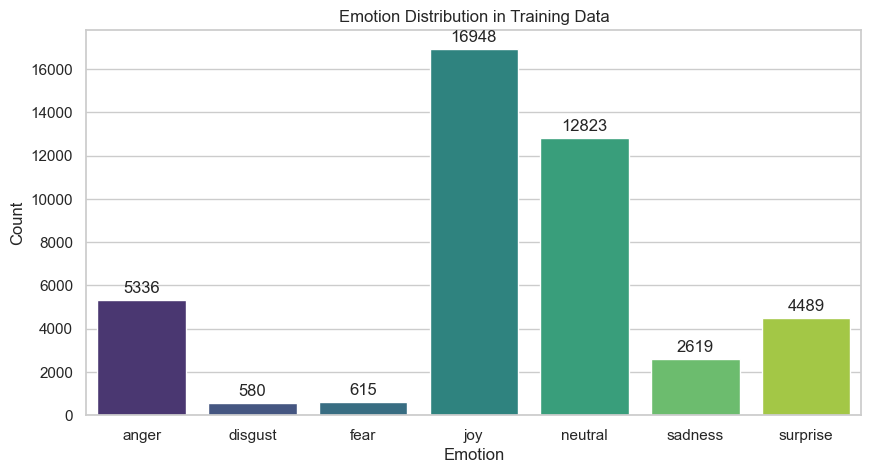

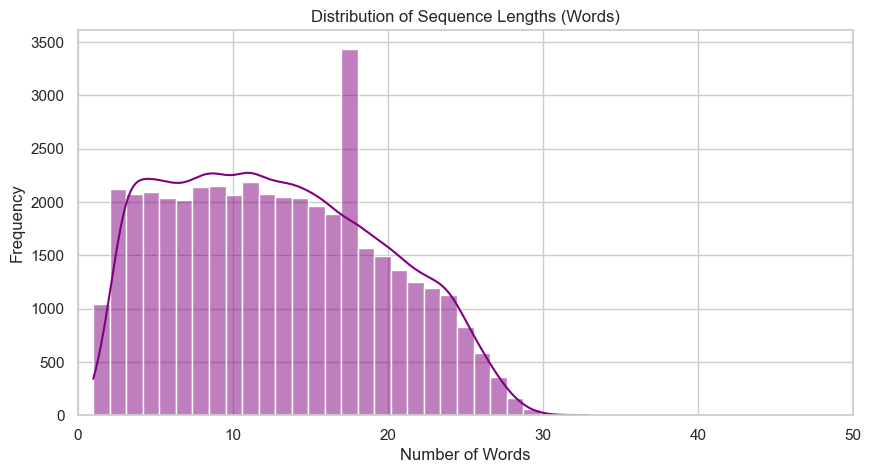

In [16]:
# Plot class distribution
plt.figure(figsize=(10, 5))
train_df['emotion_name'] = train_df['ekman_label'].apply(lambda x: ekman_labels[x])
ax = sns.countplot(data=train_df, x='emotion_name', order=ekman_labels, palette='viridis')
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.title("Emotion Distribution in Training Data")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

# Plot sequence lengths
train_df['seq_len'] = train_df['text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10, 5))
sns.histplot(train_df['seq_len'], bins=30, kde=True, color='purple')
plt.title("Distribution of Sequence Lengths (Words)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.xlim(0, 50)
plt.show()


## 3. Load Metrics from Kaggle

Metrics loaded successfully from Kaggle JSON!


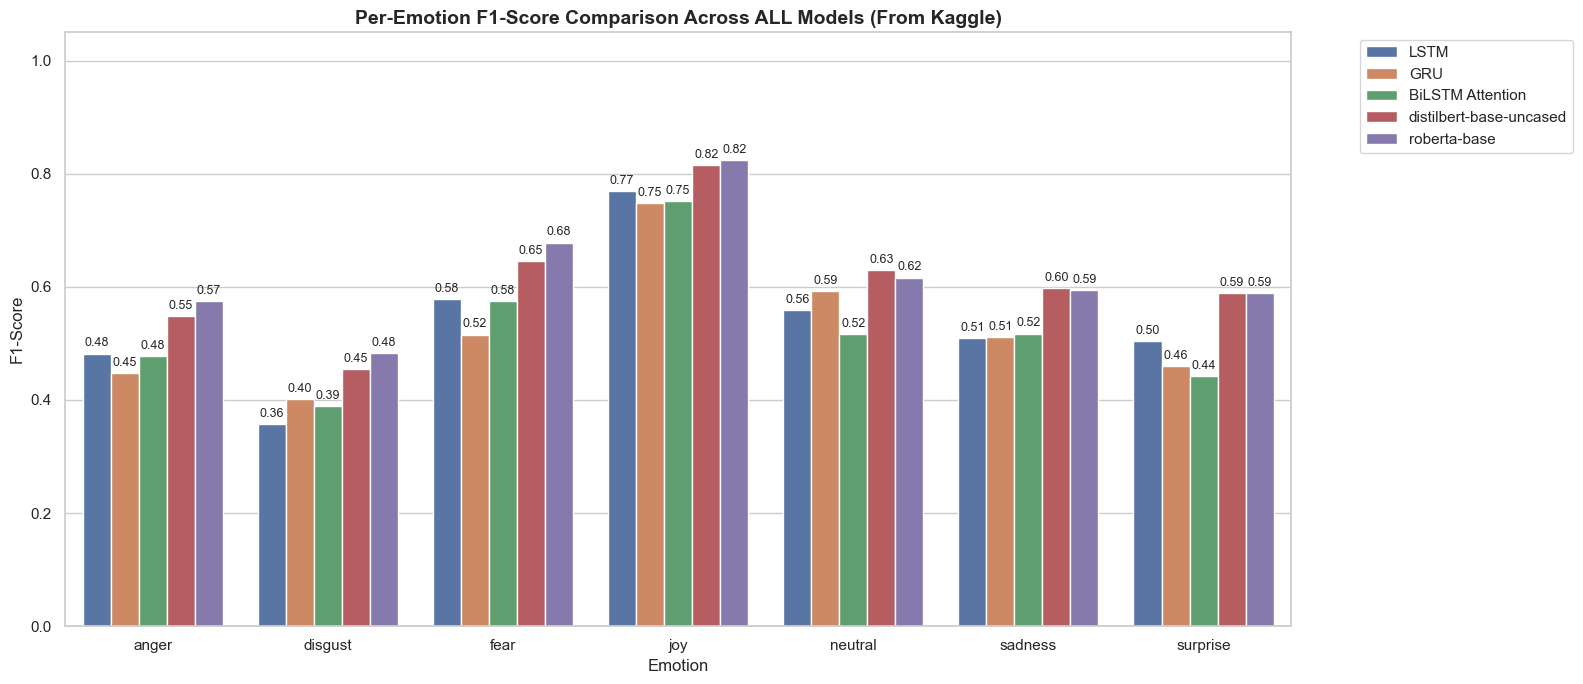

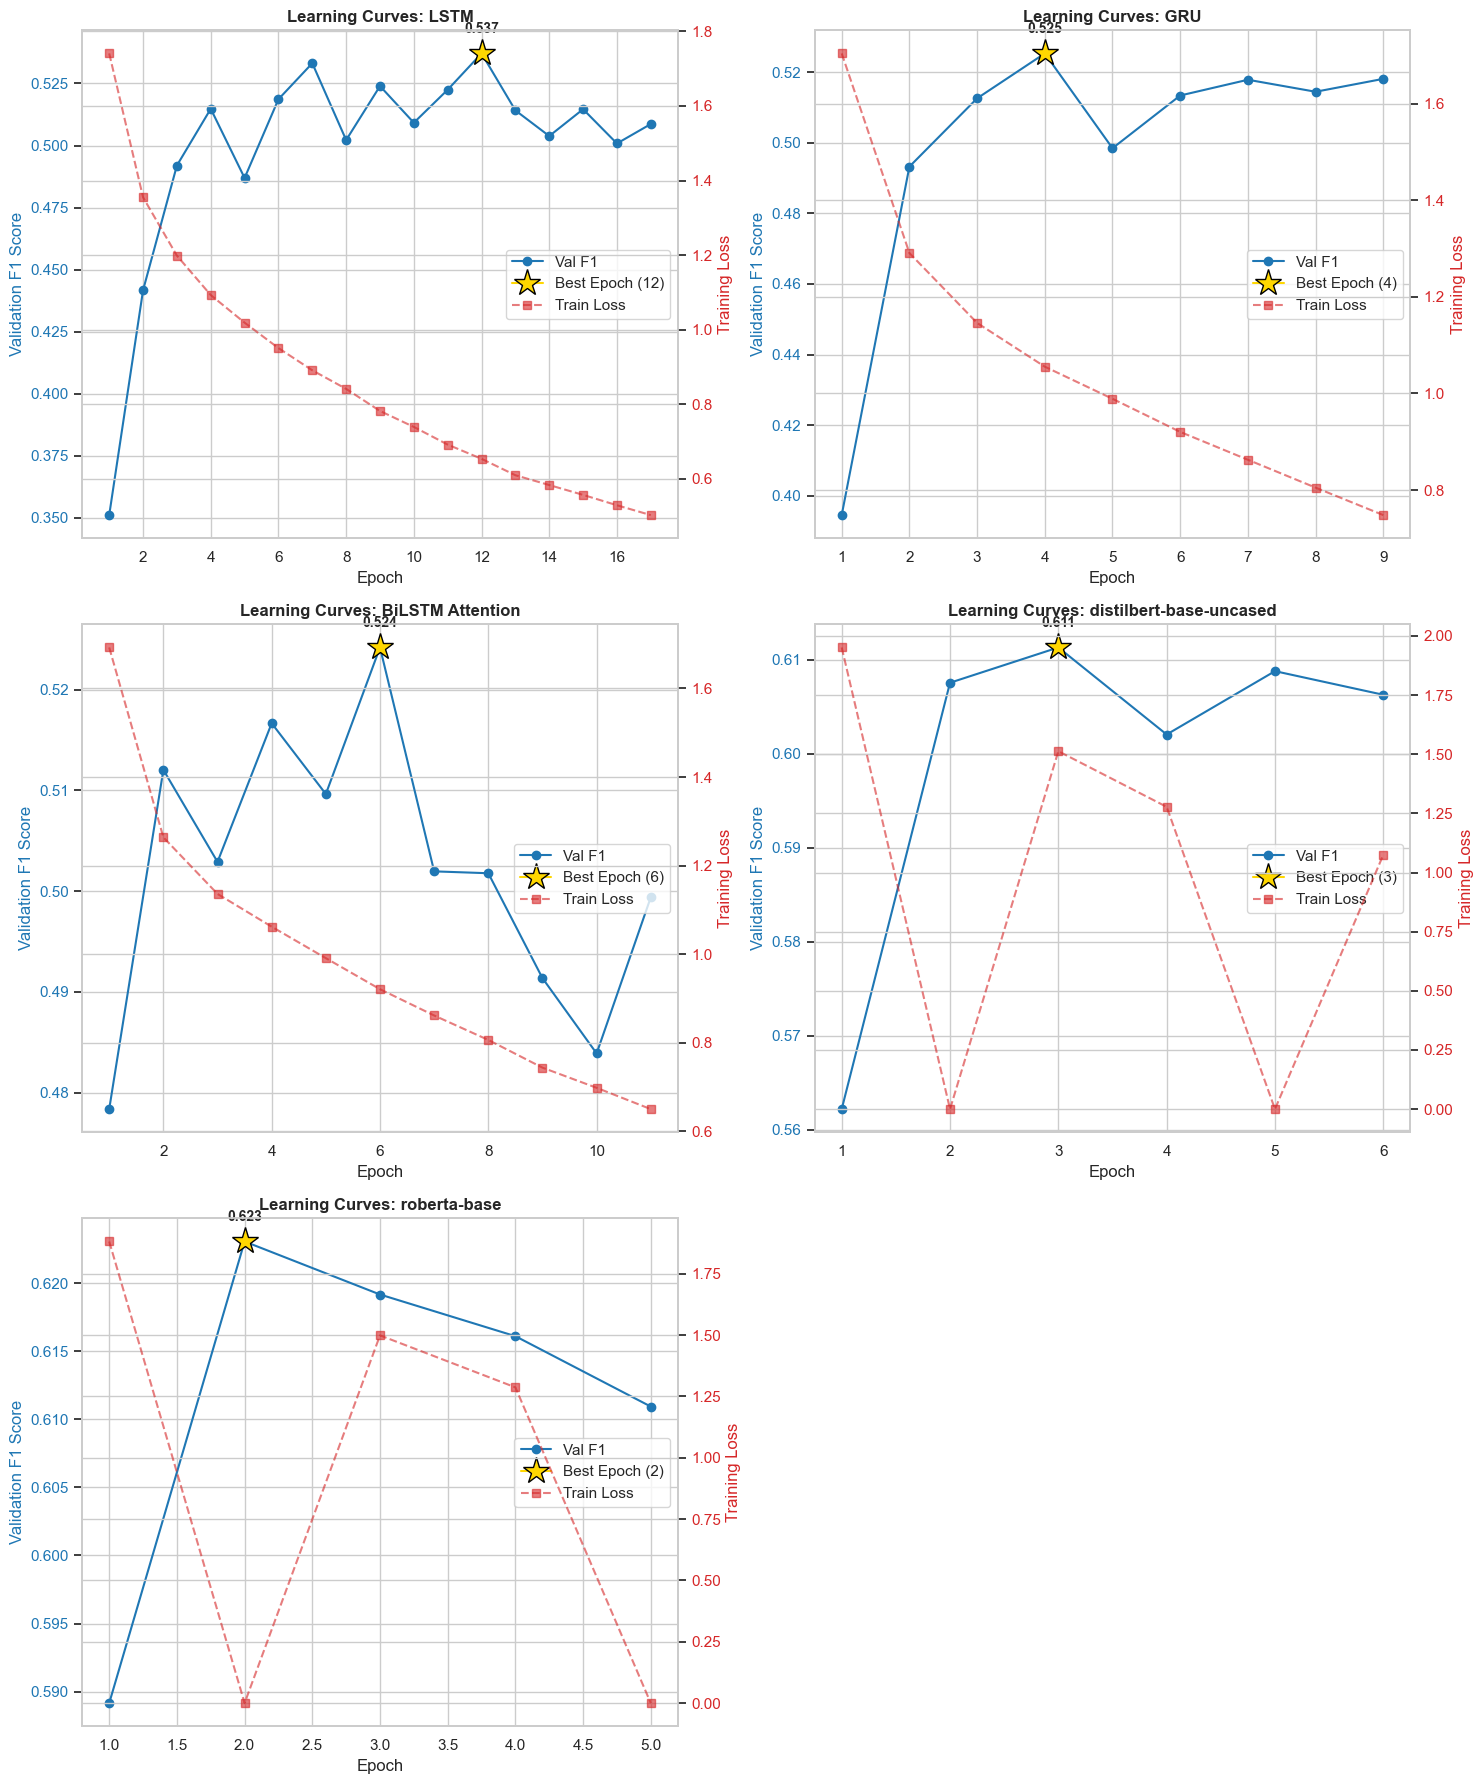

In [17]:
# Load metrics.json exported from Kaggle
try:
    with open(os.path.join(MODELS_DIR, "metrics.json"), "r") as f:
        metrics_data = json.load(f)
    print("Metrics loaded successfully from Kaggle JSON!")
    
    # Extract Per-Class Metrics
    per_class_data = []
    all_preds_dict = {} # We can't do confusion matrix for all without predictions, but we can do bar charts
    
    for m in metrics_data:
        model_name = m.get('Model')
        class_report = m.get('Per-Class Metrics', None)
        
        if class_report is not None:
            for emotion in ekman_labels:
                if emotion in class_report:
                    per_class_data.append({
                        'Model': model_name,
                        'Emotion': emotion,
                        'F1-Score': class_report[emotion]['f1-score'],
                        'Precision': class_report[emotion]['precision'],
                        'Recall': class_report[emotion]['recall']
                    })

    if len(per_class_data) > 0:
        df_plot = pd.DataFrame(per_class_data)
        
        # 1. Grouped Bar Chart
        plt.figure(figsize=(16, 7))
        ax = sns.barplot(data=df_plot, x='Emotion', y='F1-Score', hue='Model')

        # Add numbers on top of bars
        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

        plt.title("Per-Emotion F1-Score Comparison Across ALL Models (From Kaggle)", fontsize=14, fontweight='bold')
        plt.ylim(0, 1.05)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
        # 2. Plot Learning Curves (Training History)
        # We will plot the Validation F1 score across epochs for all models in a subplot or individual plots
        import math
        
        models_with_history = [m for m in metrics_data if m.get("Training History")]
        if len(models_with_history) > 0:
            num_models = len(models_with_history)
            cols = 2
            rows = math.ceil(num_models / cols)
            
            fig, axes = plt.subplots(rows, cols, figsize=(15, 6 * rows))
            axes = axes.flatten()
            
            for i, m in enumerate(models_with_history):
                model_name = m.get('Model')
                history = m.get('Training History', [])
                best_epoch = m.get('Best Epoch', -1)
                
                if len(history) == 0: continue
                
                epochs = [h['epoch'] for h in history]
                val_f1s = [h.get('val_f1', 0) for h in history]
                train_loss = [h.get('train_loss', 0) for h in history]
                
                ax1 = axes[i]
                
                # Plot Validation F1 (Primary y-axis)
                color = 'tab:blue'
                ax1.set_xlabel('Epoch')
                ax1.set_ylabel('Validation F1 Score', color=color)
                line1, = ax1.plot(epochs, val_f1s, marker='o', color=color, label='Val F1')
                ax1.tick_params(axis='y', labelcolor=color)
                
                # Highlight Best Epoch (Early Stopping Point)
                if best_epoch > 0:
                    best_idx = epochs.index(best_epoch) if best_epoch in epochs else -1
                    if best_idx != -1:
                        ax1.plot(epochs[best_idx], val_f1s[best_idx], marker='*', markersize=20, color='gold', markeredgecolor='black', label=f'Best Epoch ({best_epoch})')
                        # Annotate the point
                        ax1.annotate(f"{val_f1s[best_idx]:.3f}", 
                                     (epochs[best_idx], val_f1s[best_idx]), 
                                     textcoords="offset points", 
                                     xytext=(0,15), 
                                     ha='center', fontsize=10, fontweight='bold')

                # Plot Training Loss (Secondary y-axis)
                ax2 = ax1.twinx()
                color = 'tab:red'
                ax2.set_ylabel('Training Loss', color=color)
                line2, = ax2.plot(epochs, train_loss, marker='s', linestyle='--', color=color, alpha=0.6, label='Train Loss')
                ax2.tick_params(axis='y', labelcolor=color)
                
                # Title & Legends
                ax1.set_title(f"Learning Curves: {model_name}", fontsize=12, fontweight='bold')
                
                # Combine legends from both axes
                lines = [line1, line2]
                labels = [l.get_label() for l in lines]
                # Add best epoch marker to legend if it exists
                handles, current_labels = ax1.get_legend_handles_labels()
                ax1.legend(handles + [line2], current_labels + ['Train Loss'], loc='center right')
                
            # Hide any empty subplots
            for j in range(i + 1, len(axes)):
                fig.delaxes(axes[j])
                
            plt.tight_layout()
            plt.show()

    else:
        print("Per-Class Metrics not found in metrics.json. Please run the updated Kaggle notebook.")

except Exception as e:
    print(f"Error loading metrics.json: {e}")


## 4. Professional Interactive Inference (20 Examples)

In [18]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# 20 diverse and professional examples covering all emotions
test_sentences = [
    # Anger
    "I am completely outraged by the terrible customer service I received today.",
    "This is the last time I tolerate such blatant disrespect from anyone!",
    "My blood boils every time I think about how they lied to us.",
    "It makes me furious when people don't take responsibility for their actions.",
    # Disgust
    "The food at that restaurant was absolutely revolting and smelled awful.",
    "I felt sick to my stomach watching that horrific and graphic documentary.",
    "It's repulsive how some people treat innocent animals.",
    # Fear
    "I'm terrified of what might happen if the medical test results come back positive.",
    "Walking alone in that dark, abandoned alley sent shivers down my spine.",
    "My heart was pounding out of my chest when I heard the sudden crash.",
    # Joy
    "I am absolutely thrilled to announce that I finally got the promotion!",
    "This has been the most wonderful and perfect day of my entire life.",
    "I can't stop smiling, everything is finally falling into place perfectly!",
    "Seeing my family after so long fills my heart with immense happiness.",
    # Sadness
    "I feel incredibly empty and heartbroken after losing my best friend.",
    "It's hard to hold back tears when I think about the memories we shared.",
    "A deep sense of sorrow washed over me as I watched them leave forever.",
    # Surprise
    "I was genuinely astonished when she showed up at the door unannounced!",
    "What a shocking plot twist! I never saw that ending coming at all.",
    "I am completely blown away by the incredible detail and realism in this artwork."
]

print("Running professional inference on 20 diverse examples using RoBERTa...")
results = []
model_path = os.path.join(MODELS_DIR, 'saved_roberta-base')
if os.path.exists(model_path):
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path).to(device)
    model.eval()

    for sent in test_sentences:
        inputs = tokenizer(sent, return_tensors="pt", truncation=True, padding=True).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            probs = torch.softmax(outputs.logits, dim=-1)[0].cpu().numpy()
        
        pred_idx = np.argmax(probs)
        pred_emotion = ekman_labels[pred_idx]
        confidence = probs[pred_idx]
        
        results.append({
            "Text": sent,
            "Predicted Emotion": pred_emotion.upper(),
            "Confidence": f"{confidence:.1%}"
        })

    df_results = pd.DataFrame(results)

    def color_emotions(val):
        colors = {
            'ANGER': 'color: #ff4d4d; font-weight: bold',        # Bright Red
            'DISGUST': 'color: #ffb366; font-weight: bold',      # Light Orange/Brown
            'FEAR': 'color: #d1b2ff; font-weight: bold',         # Light Purple
            'JOY': 'color: #00ff00; font-weight: bold',          # Bright Green
            'SADNESS': 'color: #66b3ff; font-weight: bold',      # Light Blue
            'SURPRISE': 'color: #ffd700; font-weight: bold',     # Gold/Yellow
            'NEUTRAL': 'color: #cccccc; font-weight: bold'       # Light Gray
        }
        return colors.get(val, '')

    # Apply styling optimized for Dark Mode visibility
    table_styles = [
        dict(selector='th', props=[('text-align', 'left'), ('font-size', '16px'), ('border-bottom', '2px solid #555')]),
        dict(selector='td', props=[('font-size', '15px'), ('padding', '12px')])
    ]

    try:
        styled_df = df_results.style.map(color_emotions, subset=['Predicted Emotion']) \
                            .set_properties(**{'text-align': 'left'}) \
                            .set_table_styles(table_styles)
    except AttributeError:
        # Fallback for older pandas versions
        styled_df = df_results.style.applymap(color_emotions, subset=['Predicted Emotion']) \
                            .set_properties(**{'text-align': 'left'}) \
                            .set_table_styles(table_styles)
        
    display(styled_df)
else:
    print("RoBERTa model not found. Please ensure it's in the models directory.")


Running professional inference on 20 diverse examples using RoBERTa...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

,Text,Predicted Emotion,Confidence
0,I am completely outraged by the terrible customer service I received today.,ANGER,64.4%
1,This is the last time I tolerate such blatant disrespect from anyone!,ANGER,82.7%
2,My blood boils every time I think about how they lied to us.,SADNESS,73.0%
3,It makes me furious when people don't take responsibility for their actions.,ANGER,86.3%
4,The food at that restaurant was absolutely revolting and smelled awful.,DISGUST,79.8%
5,I felt sick to my stomach watching that horrific and graphic documentary.,DISGUST,40.6%
6,It's repulsive how some people treat innocent animals.,DISGUST,51.1%
7,I'm terrified of what might happen if the medical test results come back positive.,FEAR,92.0%
8,"Walking alone in that dark, abandoned alley sent shivers down my spine.",FEAR,48.0%
9,My heart was pounding out of my chest when I heard the sudden crash.,SADNESS,44.1%
